# Exploratory Data Analysis (EDA)

In [1]:
# import lib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load the cleaned dataset

df = pd.read_csv("cleaned_job_listing.csv")

df.head()

,job_id,job_role,company,experience,salary,location,rating,reviews,key_skills,posted_on,job_link,company_link,min_salary_lpa,max_salary_lpa,min_experience_years,max_experience_years
0,181224917811,Gn - Strategy - Mc - Sc&O - Sc Digital Core Ar...,Accenture,3-6 Yrs,Not disclosed,"Hyderabad, Chennai, Bengaluru",3.9,52479 Reviews,"['Sap Ariba', 'Presentation Skills', 'Solution...",1 Day Ago,https://www.naukri.com/job-listings-gn-strateg...,https://www.naukri.com/accenture-jobs-careers-...,NaN,NaN,3.0,6.0
1,181224906322,Gn - Sc&O - Bpm - Senior Manager,Accenture,2-4 Yrs,Not disclosed,"Gurugram, Bengaluru, Delhi / Ncr",3.9,52479 Reviews,"['Spend Analysis', 'Market Research', 'Sales A...",1 Day Ago,https://www.naukri.com/job-listings-gn-sc-o-bp...,https://www.naukri.com/accenture-jobs-careers-...,NaN,NaN,2.0,4.0
2,181224906320,Gn - Sc&O - S&P - Clm - Associate Manager,Accenture,1-5 Yrs,Not disclosed,"Gurugram, Bengaluru, Delhi / Ncr",3.9,52479 Reviews,"['Sourcing', 'Powerbi', 'Procurement', 'Digita...",1 Day Ago,https://www.naukri.com/job-listings-gn-sc-o-s-...,https://www.naukri.com/accenture-jobs-careers-...,NaN,NaN,1.0,5.0
3,181224904080,Gn - Song - Service - Command Center Of Future...,Accenture,12-15 Yrs,Not disclosed,"New Delhi, Gurugram, Bengaluru",3.9,52479 Reviews,"['Cloud Solutions', 'Wfm Solutions', 'Ai', 'Cu...",1 Day Ago,https://www.naukri.com/job-listings-gn-song-se...,https://www.naukri.com/accenture-jobs-careers-...,NaN,NaN,12.0,15.0
4,181224904079,Gn - Sc&O - S&P - Clm - Manager,Accenture,8-13 Yrs,Not disclosed,"New Delhi, Gurugram, Bengaluru",3.9,52479 Reviews,"['Procurement', 'Sourcing', 'Supply Chain Mana...",1 Day Ago,https://www.naukri.com/job-listings-gn-sc-o-s-...,https://www.naukri.com/accenture-jobs-careers-...,NaN,NaN,8.0,13.0


In [3]:
# check the dataset

print("Number of rows and columns:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

Number of rows and columns: (60588, 16)

Column names:
['job_id', 'job_role', 'company', 'experience', 'salary', 'location', 'rating', 'reviews', 'key_skills', 'posted_on', 'job_link', 'company_link', 'min_salary_lpa', 'max_salary_lpa', 'min_experience_years', 'max_experience_years']


In [4]:
# import ast

import ast

data is saved df to CSV, the key_skills lists were converted into text. So in this notebook, we need to convert them back into lists before counting skills.

In [5]:
# convert skills text back to lists

df["key_skills"] = df["key_skills"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith("[") else []
)

df["key_skills"].head()

0    [Sap Ariba, Presentation Skills, Solution Impl...
1    [Spend Analysis, Market Research, Sales And Op...
2    [Sourcing, Powerbi, Procurement, Digital Sourc...
3    [Cloud Solutions, Wfm Solutions, Ai, Customer ...
4    [Procurement, Sourcing, Supply Chain Managemen...
Name: key_skills, dtype: object

In [ ]:
# Which skills are most demanded

skills_df = df[["job_id", "key_skills"]].explode("key_skills")

skills_df.head()

,job_id,key_skills
0,181224917811,Sap Ariba
0,181224917811,Presentation Skills
0,181224917811,Solution Implementation
0,181224917811,Ariba
0,181224917811,Tower


In [7]:
# top 10 most demanded skills

top_skills = skills_df["key_skills"].value_counts().head(10)

top_skills

key_skills
Sales                 5541
Management            5436
Project Management    3452
Sap                   3286
Python                2675
Customer Service      2422
Analytical            2123
Javascript            2109
Css                   1920
Development           1919
Name: count, dtype: int64

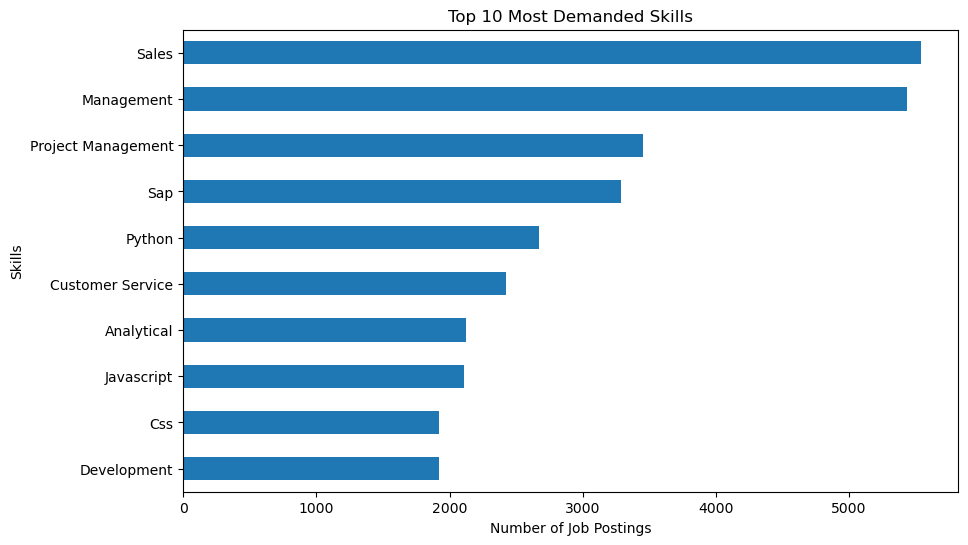

In [8]:
# visualization
# most demanded skills

plt.figure(figsize=(10, 6))

top_skills.sort_values().plot(kind="barh")

plt.title("Top 10 Most Demanded Skills")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skills")

plt.show()

Sales and Management are the most frequently demanded skills in the dataset.
Project Management and SAP are also highly demanded.
Python is one of the most demanded technical skills.

In [9]:
# Which locations have the most jobs

top_locations = df["location"].value_counts().head(10)

top_locations

location
Bengaluru                                                          8370
Pune                                                               3951
Hyderabad                                                          3818
Chennai                                                            3331
Gurugram                                                           3134
Mumbai                                                             2915
Noida                                                              2401
Ahmedabad                                                          1420
Kolkata                                                            1225
Kolkata, Mumbai, New Delhi, Hyderabad, Pune, Chennai, Bengaluru    1092
Name: count, dtype: int64

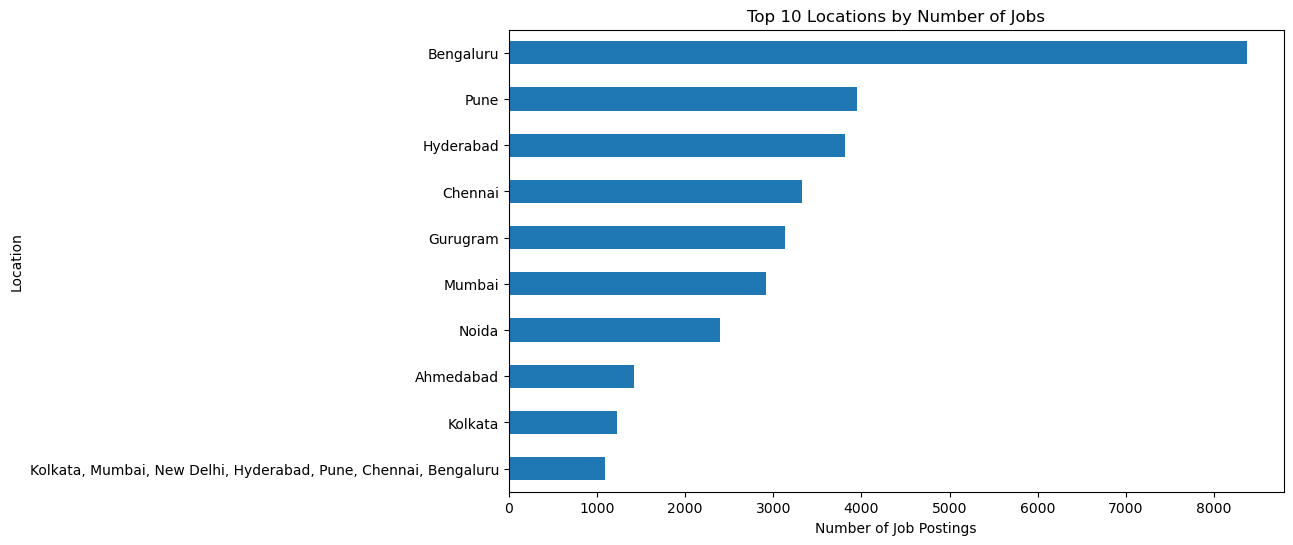

In [10]:
# visualization
# top 10 locations by number of jobs

plt.figure(figsize=(10, 6))

top_locations.sort_values().plot(kind="barh")

plt.title("Top 10 Locations by Number of Jobs")
plt.xlabel("Number of Job Postings")
plt.ylabel("Location")

plt.show()

Bengaluru has the highest number of job postings.
Pune, Hyderabad, Chennai and Gurugram also have a large number of opportunities.
This shows that major Indian technology and business hubs have a high concentration of job opportunities.

In [ ]:
# Which roles have the highest salary

df["average_salary_lpa"] = (
    df["min_salary_lpa"] + df["max_salary_lpa"]
) / 2

df[["job_role", "min_salary_lpa", "max_salary_lpa", "average_salary_lpa"]].head()

,job_role,min_salary_lpa,max_salary_lpa,average_salary_lpa
0,Gn - Strategy - Mc - Sc&O - Sc Digital Core Ar...,NaN,NaN,NaN
1,Gn - Sc&O - Bpm - Senior Manager,NaN,NaN,NaN
2,Gn - Sc&O - S&P - Clm - Associate Manager,NaN,NaN,NaN
3,Gn - Song - Service - Command Center Of Future...,NaN,NaN,NaN
4,Gn - Sc&O - S&P - Clm - Manager,NaN,NaN,NaN


In [12]:
# calculate average salary by job role

top_salary_roles = (
    df.groupby("job_role")["average_salary_lpa"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_salary_roles

job_role
Graduate Trainee - Chemistry                                    426.5
Rupeek - Relationship Trainee - Pan India                       356.0
Relationship Trainee                                            356.0
Event Management Intern                                         253.5
Solutions Delivery Leader :Banking / Loan Management Systems     80.0
Director-International Marketing-Pumps-Mnc- Coimbatore           80.0
Consultant Nephrologist                                          77.5
Site Head (Dyes & Pigments)                                      77.5
It Infrastructure And Operations Leader                          77.5
Medical Oncologist Consultant                                    75.0
Name: average_salary_lpa, dtype: float64

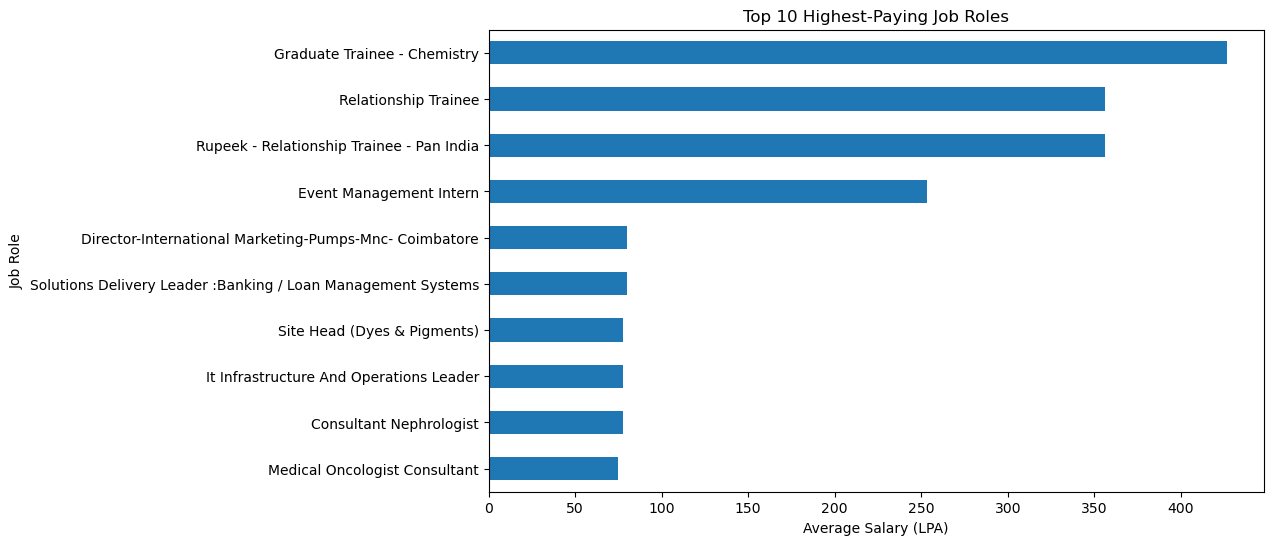

In [13]:
# visualization
# top 10 highest-paying job roles

plt.figure(figsize=(10, 6))

top_salary_roles.sort_values().plot(kind="barh")

plt.title("Top 10 Highest-Paying Job Roles")
plt.xlabel("Average Salary (LPA)")
plt.ylabel("Job Role")

plt.show()

Some specialized roles show very high average salaries.
Graduate Trainee - Chemistry and Relationship Trainee appear among the highest-paying roles in the dataset.
However, these results should be interpreted carefully because some roles may have fewer job postings and therefore their average salary can be affected by a small number of records.

In [14]:
# How does experience affect salary?

experience_salary = (
    df.groupby("min_experience_years")["average_salary_lpa"]
    .mean()
    .dropna()
)

experience_salary.head(20)

min_experience_years
0.0      6.500826
1.0      4.978008
2.0      6.112056
3.0      7.643908
4.0      9.642540
5.0     11.424810
6.0     14.304982
7.0     14.619727
8.0     16.360974
9.0     17.505297
10.0    17.357095
11.0    27.643939
12.0    20.630193
13.0    21.684524
14.0    28.169643
15.0    27.608974
16.0    33.437500
17.0    26.187500
18.0    33.633621
19.0    40.500000
Name: average_salary_lpa, dtype: float64

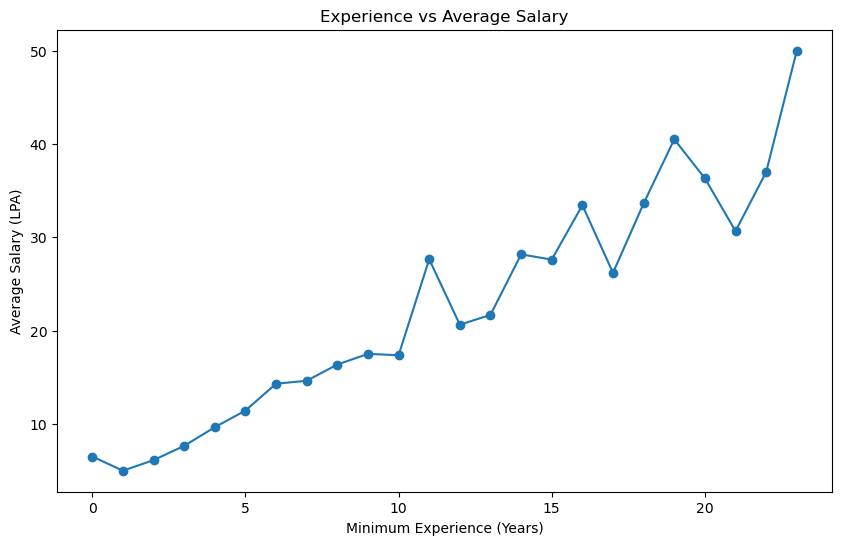

In [15]:
# visualization
# experience vs average salary

plt.figure(figsize=(10, 6))

experience_salary.plot(kind="line", marker="o")

plt.title("Experience vs Average Salary")
plt.xlabel("Minimum Experience (Years)")
plt.ylabel("Average Salary (LPA)")

plt.show()

Salary generally increases as the required experience increases.
Entry-level positions have relatively lower average salaries.
Higher-experience positions generally show higher salary levels, although there are some fluctuations.

In [ ]:
# Which companies post the most jobs

top_companies = df["company"].value_counts().head(10)

top_companies

company
Unknown               20329
Accenture              6011
Genpact                 820
Jio                     542
Bajaj Finserv Ltd.      472
IBM                     461
EY                      437
Cognizant               434
Infosys                 355
Capgemini               258
Name: count, dtype: int64

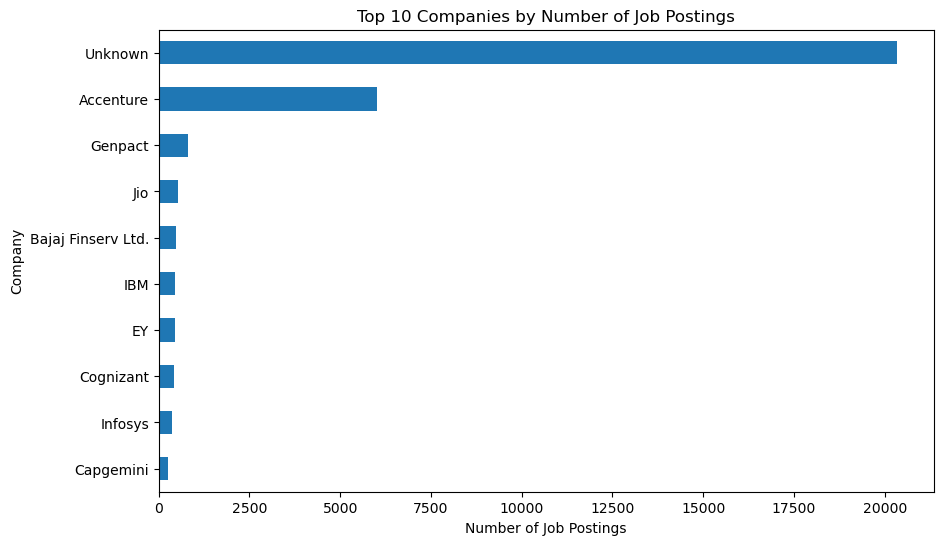

In [17]:
# visualization
# top 10 companies by number of jobs

plt.figure(figsize=(10, 6))

top_companies.sort_values().plot(kind="barh")

plt.title("Top 10 Companies by Number of Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Company")

plt.show()

Accenture has the highest number of identified company job postings.
Genpact, Jio, Bajaj Finserv Ltd., IBM and EY also have a significant number of postings.
A large number of postings have the company listed as "Unknown", so the company ranking should be considered with this limitation.